In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from datetime import timedelta
import datetime as dt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
os.chdir("/Users/sushovanmandal/Documents/code/learn-gen-ai/analyticsVidhya genAI/Foundational ML Algorithams")

In [3]:
df = pd.read_csv("nyc_taxi_trip_duration.csv", parse_dates=['pickup_datetime', 'dropoff_datetime'])

In [4]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  729322 non-null  object        
 1   vendor_id           729322 non-null  int64         
 2   pickup_datetime     729322 non-null  datetime64[ns]
 3   dropoff_datetime    729322 non-null  datetime64[ns]
 4   passenger_count     729322 non-null  int64         
 5   pickup_longitude    729322 non-null  float64       
 6   pickup_latitude     729322 non-null  float64       
 7   dropoff_longitude   729322 non-null  float64       
 8   dropoff_latitude    729322 non-null  float64       
 9   store_and_fwd_flag  729322 non-null  object        
 10  trip_duration       729322 non-null  int64         
dtypes: datetime64[ns](2), float64(4), int64(3), object(2)
memory usage: 61.2+ MB


No null values in the dataframe

In [6]:
df.shape

(729322, 11)

# Data exploration

In [7]:
#converting yes/no flag to 0 and 1
df['store_and_fwd_flag'] = 1 * (df['store_and_fwd_flag'].values == 'Y')
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,0,400
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,0,1100
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,0,1635
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,0,1141
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,0,848


In [8]:
df['check_trip_duration'] = (df['dropoff_datetime'] - df['pickup_datetime']).map(lambda x: x.total_seconds())
df[(df['check_trip_duration'] - df['trip_duration']) > 1]

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,check_trip_duration


So trip durations are matching in data and pickup, dropoff times

In [9]:
df = df.drop(columns=['check_trip_duration'])

In [10]:
df['trip_duration'].describe()/3600 # in hours

count    202.589444
mean       0.264508
std        1.073507
min        0.000278
25%        0.110278
50%        0.184167
75%        0.298611
max      538.815556
Name: trip_duration, dtype: float64

<Axes: xlabel='log_trip_duration'>

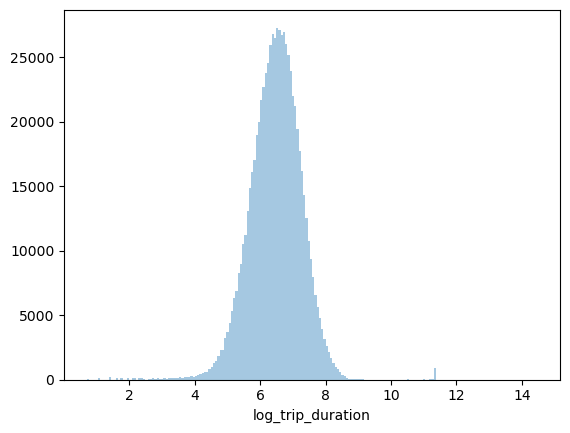

In [11]:
df['log_trip_duration'] = np.log(df['trip_duration'].values + 1)
sns.distplot(df['log_trip_duration'], kde=False, bins=200)

- The majority of rides follow a rather smooth distribution that loooks log-normal with a peak around exp(6.5) i.e. around 17 mins
- There are some suspiciously short rides with less than 10 seconds duration
- There are huge outliers near 12

In [12]:
df['day_of_week'] = df['pickup_datetime'].dt.weekday
df['hour_of_day'] = df['pickup_datetime'].dt.hour

In [13]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,log_trip_duration,day_of_week,hour_of_day
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,0,400,5.993961,0,16
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,0,1100,7.003974,4,23
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,0,1635,7.400010,6,17
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,0,1141,7.040536,1,9
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,0,848,6.744059,2,6


It would be good to keep day_of_week and hour_of_day in the predictors to capture the relationship between them and the target

We should drop the direct pickup_time and dropoff_time as dropoff time would anyways not be present in unseen data and these 2 variables together gives target directly

1 more feature we can add is minute of hour from pickup_datetime as there can be relationship there as well with target

In [15]:
df['min_of_hour'] = df['pickup_datetime'].dt.minute

In [16]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,log_trip_duration,day_of_week,hour_of_day,min_of_hour
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,0,400,5.993961,0,16,40
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,0,1100,7.003974,4,23,35
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,0,1635,7.400010,6,17,59
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,0,1141,7.040536,1,9,44
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,0,848,6.744059,2,6,42


# Prepare data for Machine Learning

We drop cols ['id', 'pickup_datetime', 'dropoff_datetime', 'log_trip_duration'] from the data used for ML training.

In [17]:
ml_data = df.drop(columns=['id', 'pickup_datetime', 'dropoff_datetime', 'log_trip_duration'])

In [18]:
ml_data.shape

(729322, 11)

In [20]:
# reshuffle the data before training
ml_data_final = ml_data.sample(frac=1, random_state=42)

In [21]:
ml_data_final.shape

(729322, 11)

In [22]:
ml_data_final.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,day_of_week,hour_of_day,min_of_hour
469114,2,1,-73.981796,40.762035,-73.972267,40.781265,0,657,5,10,40
694852,2,5,-73.980965,40.747677,-73.982704,40.741161,0,195,4,18,49
696324,1,1,-73.951065,40.782722,-73.867691,40.833664,0,840,6,0,54
356496,1,1,-73.987625,40.762791,-73.973518,40.762909,0,398,5,10,32
645318,1,3,-73.964333,40.792503,-73.988609,40.758369,0,682,6,10,45


In [24]:
X = ml_data_final.drop(columns=['trip_duration'])
y = ml_data_final['trip_duration']

In [25]:
X.shape, y.shape

((729322, 10), (729322,))

# Splitting and Training

In [55]:
#import libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
import xgboost as xgb

In [33]:
#split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 42)

In [34]:
#A quick look at the shape of the datasets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((656389, 10), (72933, 10), (656389,), (72933,))

In [56]:
xgbr = xgb.XGBRegressor(
    objective='reg:squarederror',  # default for regression
    random_state=42,
    n_jobs=-1,                     # use all cores
    tree_method='hist'             # faster training
)

In [57]:
param_dist = {
    'n_estimators': randint(100, 1000),      # 100–1000 trees
    'learning_rate': uniform(0.01, 0.29),     # 0.01–0.30
    'max_depth': randint(3, 12),             # 3–11
    'subsample': uniform(0.5, 0.5),          # 0.5–1.0
    'colsample_bytree': uniform(0.5, 0.5),   # 0.5–1.0
    'gamma': uniform(0, 5),                  # min loss reduction
    'reg_alpha': uniform(0, 1),              # L1 regularization
    'reg_lambda': uniform(0.5, 1.5)           # L2 regularization
}

In [58]:
cv_folds = KFold(n_splits=5, shuffle=True, random_state=42)

In [59]:
random_search = RandomizedSearchCV(
    estimator=xgbr,
    param_distributions=param_dist,
    n_iter=60,                    # 60 candidates → fast (~5–30 min on most datasets)
    cv=cv_folds,
    scoring='r2',
    n_jobs=-1,                    # parallel across cores
    random_state=42,
    verbose=1
)

In [60]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': <scipy.stats....t 0x1751d6b40>, 'gamma': <scipy.stats....t 0x1751d6a50>, 'learning_rate': <scipy.stats....t 0x1751d51f0>, 'max_depth': <scipy.stats....t 0x1751d4d10>, ...}"
,n_iter,60
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [61]:
random_search.best_params_

{'colsample_bytree': np.float64(0.607294559854187),
 'gamma': np.float64(1.8862954161398793),
 'learning_rate': np.float64(0.021299308369967754),
 'max_depth': 4,
 'n_estimators': 134,
 'reg_alpha': np.float64(0.3365542148887265),
 'reg_lambda': np.float64(1.4835839530711132),
 'subsample': np.float64(0.6926983104827825)}

In [62]:
random_search.best_score_

np.float64(0.0002777695655822754)

In [51]:
best_dt = random_search.best_estimator_

In [52]:
y_pred = best_dt.predict(X_test)

In [54]:
r2_score(y_test, y_pred)

0.017102421289474923

Even with XGBoost Regressor, the r2 score is very low in both train and test sets.

# Trying out Decision Tree Regressor

In [63]:
# Import DecisionTreeRegressor from sklearn.tree
from sklearn.tree import DecisionTreeRegressor

In [64]:
# Creating a decision tree classifier object called DT_model
DT_model = DecisionTreeRegressor(random_state = 42)

In [65]:
# Building the model using the training data
DT_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [66]:
# Perfoming prediction on both the train and test data
y_pred_train = DT_model.predict(X_train)
y_pred_test = DT_model.predict(X_test)

In [67]:
r2_train = r2_score(y_train, y_pred_train)
r2_train

1.0

In [68]:
r2_test = r2_score(y_test, y_pred_test)
r2_test

-1.1635009613938228

In [69]:
#Retreiving the score of each feature
feature_imp = DT_model.feature_importances_

#  Sort the features by importance in descending order in a dataframe.
imp = pd.DataFrame({'Col_names': X_train.columns, 'Importance': feature_imp}).sort_values(by='Importance', ascending=False)
# Calculate the cumulative sum of the 'Importance' column and store it in a new column called 'cum_imp'
imp['cum_imp'] = imp.Importance.cumsum()
imp

,Col_names,Importance,cum_imp
4,dropoff_longitude,0.487175,0.487175
5,dropoff_latitude,0.138667,0.625843
3,pickup_latitude,0.126887,0.752729
2,pickup_longitude,0.116292,0.869021
9,min_of_hour,0.042120,0.911141
8,hour_of_day,0.036788,0.947929
7,day_of_week,0.033084,0.981013
1,passenger_count,0.017068,0.998081
0,vendor_id,0.001258,0.999339
6,store_and_fwd_flag,0.000661,1.000000


In [70]:
drop_col = imp[imp.cum_imp >  0.99]['Col_names'].to_list()
drop_col

['passenger_count', 'vendor_id', 'store_and_fwd_flag']

In [71]:
# Dropping the columns from X_train
X_train.drop(columns = drop_col, axis = 1, inplace = True)

In [72]:
# Dropping the columns from X_test
X_test.drop(columns = drop_col, axis = 1, inplace = True)

In [73]:
DT_model = DecisionTreeRegressor(random_state = 42)

In [74]:
DT_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [75]:
y_pred = DT_model.predict(X_test)

In [76]:
y_pred_train = DT_model.predict(X_train)

In [77]:
r2 = r2_score(y_train, y_pred_train)
r2

1.0

In [78]:
r2 = r2_score(y_test, y_pred)
r2

-1.1496671755652734

In [79]:
# Storing the depth used by default in the model
depth = DT_model.get_depth()

In [80]:
depth

63

In [81]:
# List of max_depth values 
max_depth_list = list(range(depth,0,-3))

In [82]:
# Dictionary to store the train and test r square scores

train_scores = {}
test_scores = {}

# Loop through max_depth values and train the models
for depth in max_depth_list:
    # Initialize the Decision Tree model with the current max_depth value
    DT_model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    
    # Train the model
    DT_model.fit(X_train, y_train)
    
    # Make predictions on the train dataset
    y_train_pred = DT_model.predict(X_train)

    # Make predictions on the test dataset
    y_test_pred = DT_model.predict(X_test)
    
    # Store the train r square score in the dictionary with the max_depth as the key
    train_scores[depth] = r2_score(y_train, y_train_pred)
    
    # Store the test r square score in the dictionary with the max_depth as the key
    test_scores[depth] = r2_score(y_test, y_test_pred)
    

# Print the train and test r square scores for each model
for depth in max_depth_list:
    print(f"max_depth = {depth}|\
    Train Score = {train_scores[depth]:.3f} |\
    Test score = {test_scores[depth]:.3f}")
    print('_'*65)

max_depth = 63|    Train Score = 1.000 |    Test score = -1.150
_________________________________________________________________
max_depth = 60|    Train Score = 1.000 |    Test score = -1.150
_________________________________________________________________
max_depth = 57|    Train Score = 1.000 |    Test score = -1.135
_________________________________________________________________
max_depth = 54|    Train Score = 1.000 |    Test score = -1.205
_________________________________________________________________
max_depth = 51|    Train Score = 1.000 |    Test score = -1.207
_________________________________________________________________
max_depth = 48|    Train Score = 1.000 |    Test score = -1.168
_________________________________________________________________
max_depth = 45|    Train Score = 1.000 |    Test score = -1.116
_________________________________________________________________
max_depth = 42|    Train Score = 1.000 |    Test score = -1.227
__________________________

Only Underfit models are getting some positive r2 score on the test set, otherwise -ve r2 score in test set

# Let's try to remove outliers before model fitting

In [83]:
ml_data.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,day_of_week,hour_of_day,min_of_hour
count,729322.000000,729322.000000,729322.000000,729322.000000,729322.000000,729322.000000,729322.000000,7.293220e+05,729322.000000,729322.000000,729322.000000
mean,1.535403,1.662055,-73.973513,40.750919,-73.973422,40.751775,0.005539,9.522291e+02,3.049081,13.611698,29.597785
std,0.498745,1.312446,0.069754,0.033594,0.069588,0.036037,0.074221,3.864626e+03,1.954470,6.402853,17.332400
min,1.000000,0.000000,-121.933342,34.712234,-121.933304,32.181141,0.000000,1.000000e+00,0.000000,0.000000,0.000000
25%,1.000000,1.000000,-73.991859,40.737335,-73.991318,40.735931,0.000000,3.970000e+02,1.000000,9.000000,15.000000
50%,2.000000,1.000000,-73.981758,40.754070,-73.979759,40.754509,0.000000,6.630000e+02,3.000000,14.000000,30.000000
75%,2.000000,2.000000,-73.967361,40.768314,-73.963036,40.769741,0.000000,1.075000e+03,5.000000,19.000000,45.000000
max,2.000000,9.000000,-65.897385,51.881084,-65.897385,43.921028,1.000000,1.939736e+06,6.000000,23.000000,59.000000


In [84]:
ml_data['trip_duration'].describe()

count    7.293220e+05
mean     9.522291e+02
std      3.864626e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.630000e+02
75%      1.075000e+03
max      1.939736e+06
Name: trip_duration, dtype: float64

In [85]:
# Step 1: Calculate Q1, Q3, and IQR
Q1 = df['trip_duration'].quantile(0.25)
Q3 = df['trip_duration'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")

Q1: 397.0, Q3: 1075.0, IQR: 678.0


In [86]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Lower bound: -620.0, Upper bound: 2092.0


Let's set a more reasonable lower bound, 30 secs, since 30 sec trip is a half minute trip

In [87]:
lower_bound = 30

In [88]:
# Step 3: Filter out outliers
ml_data_clean = ml_data[(ml_data['trip_duration'] >= lower_bound) & (ml_data['trip_duration'] <= upper_bound)]

In [89]:
print("Shape after removing outliers:", ml_data_clean.shape)
print("Outliers removed:", ml_data.shape[0] - ml_data_clean.shape[0])

Shape after removing outliers: (689984, 11)
Outliers removed: 39338


In [90]:
# reshuffle the data before training
ml_data_final = ml_data_clean.sample(frac=1, random_state=42)

In [91]:
ml_data_final.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,day_of_week,hour_of_day,min_of_hour
419494,1,1,-73.995079,40.739803,-73.981178,40.771671,0,2085,0,11,57
728882,1,4,-73.952271,40.798077,-73.944122,40.776512,0,748,4,18,11
492080,2,2,-73.980850,40.689213,-73.996384,40.693367,0,1344,2,22,3
374954,2,2,-74.002350,40.724682,-73.988861,40.726986,0,422,2,18,26
685288,2,1,-73.972832,40.764481,-73.985176,40.742043,0,1450,3,18,50


In [92]:
X = ml_data_final.drop(columns=['trip_duration'])
y = ml_data_final['trip_duration']

In [93]:
X.shape, y.shape

((689984, 10), (689984,))

In [94]:
#split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [95]:
#A quick look at the shape of the datasets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((551987, 10), (137997, 10), (551987,), (137997,))

# Decision Tree Regressor on outlier cleaned data

In [96]:
# Creating a decision tree classifier object called DT_model
DT_model = DecisionTreeRegressor(random_state = 42)

In [97]:
# Building the model using the training data
DT_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [98]:
# Perfoming prediction on both the train and test data
y_pred_train = DT_model.predict(X_train)
y_pred_test = DT_model.predict(X_test)

In [99]:
r2_train = r2_score(y_train, y_pred_train)
r2_train

1.0

In [100]:
r2_test = r2_score(y_test, y_pred_test)
r2_test

0.498699208711347

Already we see huge improvement in the test r2 score

In [101]:
#Retreiving the score of each feature
feature_imp = DT_model.feature_importances_

#  Sort the features by importance in descending order in a dataframe.
imp = pd.DataFrame({'Col_names': X_train.columns, 'Importance': feature_imp}).sort_values(by='Importance', ascending=False)
# Calculate the cumulative sum of the 'Importance' column and store it in a new column called 'cum_imp'
imp['cum_imp'] = imp.Importance.cumsum()
imp

,Col_names,Importance,cum_imp
3,pickup_latitude,0.267570,0.267570
5,dropoff_latitude,0.203920,0.471490
2,pickup_longitude,0.203401,0.674891
4,dropoff_longitude,0.193813,0.868705
8,hour_of_day,0.058044,0.926748
9,min_of_hour,0.030369,0.957117
7,day_of_week,0.029589,0.986706
1,passenger_count,0.008276,0.994982
0,vendor_id,0.004613,0.999594
6,store_and_fwd_flag,0.000406,1.000000


In [102]:
drop_col = imp[imp.cum_imp >  0.99]['Col_names'].to_list()
drop_col

['passenger_count', 'vendor_id', 'store_and_fwd_flag']

In [103]:
# Dropping the columns from X_train
X_train.drop(columns = drop_col, axis = 1, inplace = True)

In [104]:
# Dropping the columns from X_test
X_test.drop(columns = drop_col, axis = 1, inplace = True)

In [105]:
DT_model = DecisionTreeRegressor(random_state = 42)

In [106]:
DT_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [107]:
# Perfoming prediction on both the train and test data
y_pred_train = DT_model.predict(X_train)
y_pred_test = DT_model.predict(X_test)

In [108]:
r2_train = r2_score(y_train, y_pred_train)
r2_train

1.0

In [109]:
r2_test = r2_score(y_test, y_pred_test)
r2_test

0.5002395358609906

further improvement in r2 score

In [111]:
# Storing the depth used by default in the model
depth = DT_model.get_depth()
depth

58

In [112]:
# List of max_depth values 
max_depth_list = list(range(depth,0,-3))

In [113]:
# Dictionary to store the train and test r square scores

train_scores = {}
test_scores = {}

# Loop through max_depth values and train the models
for depth in max_depth_list:
    # Initialize the Decision Tree model with the current max_depth value
    DT_model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    
    # Train the model
    DT_model.fit(X_train, y_train)
    
    # Make predictions on the train dataset
    y_train_pred = DT_model.predict(X_train)

    # Make predictions on the test dataset
    y_test_pred = DT_model.predict(X_test)
    
    # Store the train r square score in the dictionary with the max_depth as the key
    train_scores[depth] = r2_score(y_train, y_train_pred)
    
    # Store the test r square score in the dictionary with the max_depth as the key
    test_scores[depth] = r2_score(y_test, y_test_pred)
    

# Print the train and test r square scores for each model
for depth in max_depth_list:
    print(f"max_depth = {depth}|\
    Train Score = {train_scores[depth]:.3f} |\
    Test score = {test_scores[depth]:.3f}")
    print('_'*65)

max_depth = 58|    Train Score = 1.000 |    Test score = 0.500
_________________________________________________________________
max_depth = 55|    Train Score = 1.000 |    Test score = 0.501
_________________________________________________________________
max_depth = 52|    Train Score = 1.000 |    Test score = 0.499
_________________________________________________________________
max_depth = 49|    Train Score = 1.000 |    Test score = 0.499
_________________________________________________________________
max_depth = 46|    Train Score = 1.000 |    Test score = 0.500
_________________________________________________________________
max_depth = 43|    Train Score = 1.000 |    Test score = 0.499
_________________________________________________________________
max_depth = 40|    Train Score = 0.998 |    Test score = 0.500
_________________________________________________________________
max_depth = 37|    Train Score = 0.995 |    Test score = 0.504
__________________________________

In [114]:
# Dictionary to store the train and test r square scores

train_scores = {}
test_scores = {}

# Fill the values in the below list and assign value to the variable!
min_sample_leaf_list = [1, 2, 4, 7, 10]
depth = 16

# Loop through min_sample_leaf values and train the models
for min_sample_leaf in min_sample_leaf_list:
    
    # Initialize the Decision Tree model with the current min_samples_leaf value
    DT_model = DecisionTreeRegressor(min_samples_leaf=min_sample_leaf, max_depth=depth, random_state=42)
    
    # Train the model
    DT_model.fit(X_train, y_train)
    
    # Make predictions on the train dataset
    y_train_pred = DT_model.predict(X_train)

    # Make predictions on the test dataset
    y_test_pred = DT_model.predict(X_test)
    
    # Store the train r square score in the dictionary with the min_sample_leaf as the key
    train_scores[min_sample_leaf] = r2_score (y_train, y_train_pred)
    
    # Store the test r square score in the dictionary with the min_sample_leaf as the key
    test_scores[min_sample_leaf] = r2_score (y_test, y_test_pred)
    

# Print the train and test r square scores for each model
for min_sample_leaf in min_sample_leaf_list:
    print(f"min_sample_leaf = {min_sample_leaf}|\
    Train Score = {train_scores[min_sample_leaf]:.3f} |\
    Test Score = {test_scores[min_sample_leaf]:.3f}")
    print('_'*65)

min_sample_leaf = 1|    Train Score = 0.679 |    Test Score = 0.600
_________________________________________________________________
min_sample_leaf = 2|    Train Score = 0.677 |    Test Score = 0.603
_________________________________________________________________
min_sample_leaf = 4|    Train Score = 0.673 |    Test Score = 0.609
_________________________________________________________________
min_sample_leaf = 7|    Train Score = 0.667 |    Test Score = 0.613
_________________________________________________________________
min_sample_leaf = 10|    Train Score = 0.663 |    Test Score = 0.615
_________________________________________________________________


with max_depth=16, and min_sample_leaf = 10, we get 0.663 and 0.615 train and test r2 scores, much better than what we were getting earlier

# Let's retry XGBoost Regressor now

In [116]:
xgbr = xgb.XGBRegressor(
    objective='reg:squarederror',  # default for regression
    random_state=42,
    n_jobs=-1,                     # use all cores
    tree_method='hist'             # faster training
)

In [117]:
param_dist = {
    'n_estimators': randint(100, 1000),      # 100–1000 trees
    'learning_rate': uniform(0.01, 0.29),     # 0.01–0.30
    'max_depth': randint(3, 12),             # 3–11
    'subsample': uniform(0.5, 0.5),          # 0.5–1.0
    'colsample_bytree': uniform(0.5, 0.5),   # 0.5–1.0
    'gamma': uniform(0, 5),                  # min loss reduction
    'reg_alpha': uniform(0, 1),              # L1 regularization
    'reg_lambda': uniform(0.5, 1.5)           # L2 regularization
}

In [118]:
cv_folds = KFold(n_splits=5, shuffle=True, random_state=42)

In [119]:
random_search = RandomizedSearchCV(
    estimator=xgbr,
    param_distributions=param_dist,
    n_iter=60,                    # 60 candidates → fast (~5–30 min on most datasets)
    cv=cv_folds,
    scoring='r2',
    n_jobs=-1,                    # parallel across cores
    random_state=42,
    verbose=1
)

In [120]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': <scipy.stats....t 0x1751f87d0>, 'gamma': <scipy.stats....t 0x1751f9340>, 'learning_rate': <scipy.stats....t 0x16c578d70>, 'max_depth': <scipy.stats....t 0x1751f91f0>, ...}"
,n_iter,60
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [121]:
random_search.best_params_

{'colsample_bytree': np.float64(0.8658238776498202),
 'gamma': np.float64(0.638448647112328),
 'learning_rate': np.float64(0.08250477027267034),
 'max_depth': 10,
 'n_estimators': 762,
 'reg_alpha': np.float64(0.9307573256035647),
 'reg_lambda': np.float64(1.7876191277645177),
 'subsample': np.float64(0.7144970136875092)}

In [122]:
random_search.best_score_

np.float64(0.7759003281593323)

In [123]:
best_xgbr = random_search.best_estimator_

In [124]:
y_pred = best_xgbr.predict(X_test)

In [125]:
r2_score(y_test, y_pred)

0.7739391922950745

Now we get a much better consistent XGBRegressor which gives r2 score of 0.776 in train data and 0.774 on test data

In [128]:
mse = mean_squared_error(y_test, y_pred)

In [129]:
rmse = np.sqrt(mse)

In [130]:
print(f"MSE on test data: {mse:.4f}")
print(f"RMSE on test data: {rmse:.4f}")

MSE on test data: 45070.8867
RMSE on test data: 212.2991


rmse of 212 corresponds to 3.5 mins approx. error on prediction